# Live Project - 1

### 1. Import Modules

In [1]:
!python -m pip install -r requirements.txt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable


### 2. Load Dataset

In [2]:
df = pd.read_csv('./Q1_Sales_Data.csv')

df

,Date,Product,Region,CustomerID,Quantity,Sales,Revenue
0,2025-02-16,Printer,East,CUST0065,8,146.77,1174.16
1,2025-03-28,Monitor,South,CUST0032,3,587.17,1761.51
2,2025-03-27,Keyboard,East,CUST0034,2,738.15,1476.30
3,2025-01-02,Printer,West,CUST0092,1,883.87,883.87
4,2025-01-17,Tablet,North,CUST0095,3,742.68,2228.04
...,...,...,...,...,...,...,...
500,2025-03-23,Smartphone,South,CUST0007,8,698.42,5587.36
501,2025-03-08,Tablet,South,CUST0074,4,656.06,2624.24
502,2025-02-26,Printer,South,CUST0052,8,472.72,3781.76
503,2025-02-02,Laptop,West,CUST0079,1,104.45,104.45


### 3. Data Cleaning

In [3]:
df.isna().sum()

Date           0
Product        0
Region         0
CustomerID     0
Quantity       0
Sales         15
Revenue       15
dtype: int64

In [4]:
df[["Sales", "Revenue"]] = df[["Sales", "Revenue"]].fillna(df[["Sales", "Revenue"]].mean())

df.isna().sum()

Date          0
Product       0
Region        0
CustomerID    0
Quantity      0
Sales         0
Revenue       0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(5)

In [6]:
df.drop_duplicates()

,Date,Product,Region,CustomerID,Quantity,Sales,Revenue
0,2025-02-16,Printer,East,CUST0065,8,146.770000,1174.16
1,2025-03-28,Monitor,South,CUST0032,3,587.170000,1761.51
2,2025-03-27,Keyboard,East,CUST0034,2,738.150000,1476.30
3,2025-01-02,Printer,West,CUST0092,1,883.870000,883.87
4,2025-01-17,Tablet,North,CUST0095,3,742.680000,2228.04
...,...,...,...,...,...,...,...
495,2025-02-11,Mouse,East,CUST0029,3,551.856755,494.64
496,2025-01-16,Laptop,North,CUST0049,6,164.130000,984.78
497,2025-01-19,Monitor,North,CUST0045,9,110.900000,998.10
498,2025-02-14,Smartphone,West,CUST0093,6,960.850000,5765.10


In [7]:
df["Date"] = pd.to_datetime(df["Date"])

In [8]:
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

### 4. Summary Statistics

In [9]:
df[["Sales", "Quantity", "Revenue"]].describe()

,Sales,Quantity,Revenue
count,505.000000,505.000000,505.000000
mean,551.856755,4.936634,2708.478571
std,257.898306,2.664423,2036.354084
min,104.450000,1.000000,104.450000
25%,322.390000,2.000000,1047.450000
50%,551.856755,5.000000,2181.440000
75%,759.800000,7.000000,3895.570000
max,999.470000,9.000000,8995.230000


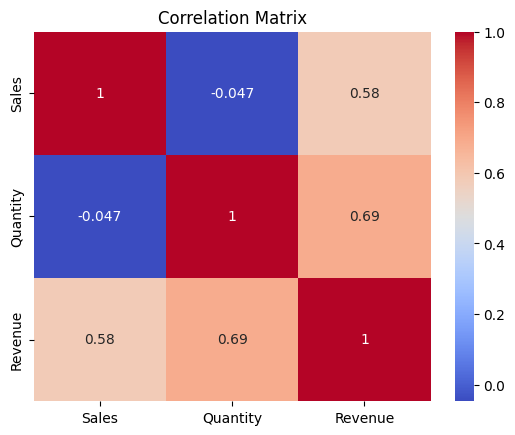

In [10]:
corr_df = df[["Sales", "Quantity", "Revenue"]].corr()

sns.heatmap(corr_df, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### 5. Top-performing Products 

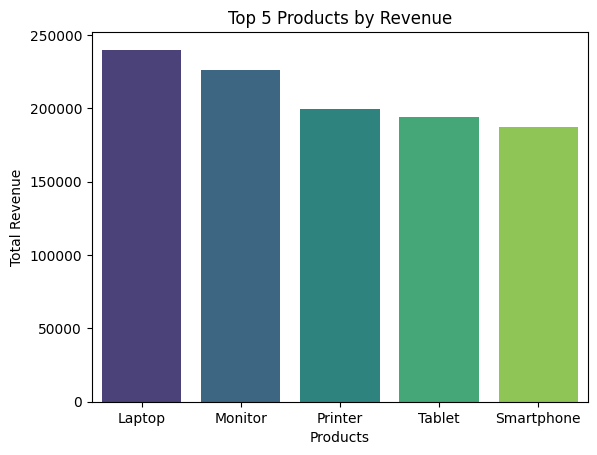

In [11]:
top_5_products = df.groupby("Product")["Revenue"].sum().nlargest(5)
sns.barplot(y=top_5_products.values, x=top_5_products.index, palette="viridis", hue=top_5_products.index)
plt.title("Top 5 Products by Revenue")
plt.ylabel("Total Revenue")
plt.xlabel("Products")
plt.show()

### 6. Sales Performance over Time

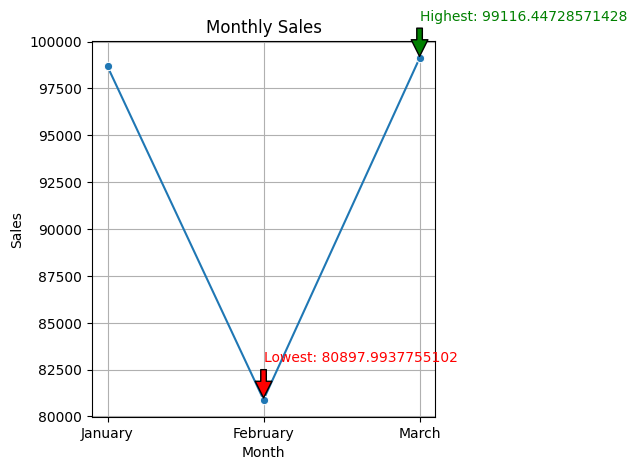

In [12]:
monthly_sales = df.groupby("Month")["Sales"].sum()

calendar = pd.Series(["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"], index=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

# make line plot with annotations showing highest and lowest points
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker="o")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(ticks=monthly_sales.index, labels=calendar[monthly_sales.index])
plt.grid()

# Annotate highest and lowest points
max_month = monthly_sales.idxmax()
max_value = monthly_sales.max()
min_month = monthly_sales.idxmin()
min_value = monthly_sales.min()
plt.annotate(f"Highest: {max_value}", xy=(max_month, max_value), xytext=(max_month, max_value + 2000),
             arrowprops=dict(facecolor='green', shrink=0.05), color='green')
plt.annotate(f"Lowest: {min_value}", xy=(min_month, min_value), xytext=(min_month, min_value + 2000),
             arrowprops=dict(facecolor='red', shrink=0.05), color='red')

plt.tight_layout()
plt.show()

### 7. Geographical Insights

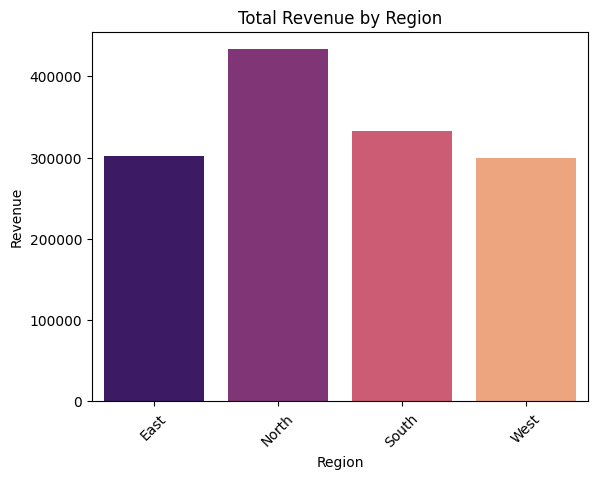

In [13]:
"""
Geographical Insights:
○ Group sales by region and visualize the total revenue per region using a bar chart.
○ Identify the region with the highest sales growth and explain the trend.
"""
sales_by_region = df.groupby("Region")["Revenue"].sum()
sns.barplot(x=sales_by_region.index, y=sales_by_region.values, palette="magma", hue=sales_by_region.index)
plt.title("Total Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


### 8. Customer Behavior Analysis

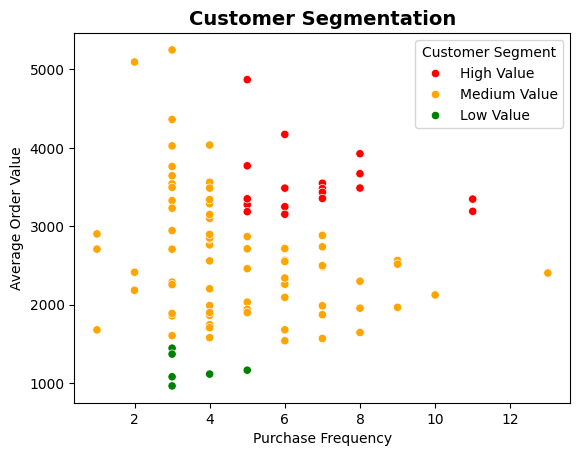

In [14]:
# Aggregate customer purchase behavior
customer_data = df.groupby("CustomerID").agg({
    "Sales": "count",
    "Revenue": "mean"
}).rename(columns={
    "Sales": "Purchase Frequency",
    "Revenue": "Average Order Value"
})

# Categorize customers
def categorize_customer(row):
    if row["Purchase Frequency"] >= 5 and row["Average Order Value"] >= 3000:
        return "High Value"
    elif row["Average Order Value"] >= 1500:
        return "Medium Value"
    else:
        return "Low Value"

customer_data["Customer Segment"] = customer_data.apply(categorize_customer, axis=1)

# Define colors for segments (explicit mapping ensures correct legend order)
segment_palette = {
    "High Value": "red",
    "Medium Value": "orange",
    "Low Value": "green"
}

# Plot scatterplot with consistent legend order
sns.scatterplot(
    data=customer_data,
    x="Purchase Frequency",
    y="Average Order Value",
    hue="Customer Segment",
    palette=segment_palette,
    hue_order=["High Value", "Medium Value", "Low Value"]  # ensures correct legend order
)

# Titles and labels
plt.title("Customer Segmentation", fontsize=14, fontweight="bold")
plt.xlabel("Purchase Frequency")
plt.ylabel("Average Order Value")

# Show plot
plt.show()